In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_reader import DataReader
from statsmodels.tsa.seasonal import STL
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from datetime import datetime

# 1. Cargar datasets

In [2]:
data_reader = DataReader()
coVar_data, rr_data, tg_data, tn_data, tx_data, master_data = data_reader.read_data().values()
ids_list = list(coVar_data['Id'].unique())

In [4]:
# Id de las estaciones disponibles y cantidad de estaciones
print(ids_list)
print(len(ids_list))

[229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 309, 335, 336, 337, 412, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 1389, 1392, 1393, 1394, 1395, 1396, 1397, 1398, 1399, 1401, 1404, 1405, 1406, 2969, 3838, 3839, 3903, 3904, 3905, 3906, 3907, 3908, 3909, 3910, 3911, 3912, 3913, 3914, 3915, 3916, 3917, 3918, 3919, 3920, 3921, 3922, 3923, 3924, 3925, 3926, 3927, 3928, 3929, 3930, 3931, 3932, 3933, 3934, 3935, 3937, 3938, 3939, 3942, 3943, 3944, 3945, 3946, 3947, 3948, 3949, 3950, 3951, 3952, 3953, 3954, 3955, 3956, 3961, 3962, 3963, 3964, 3965, 3966, 3967, 3968, 3969, 3970, 3971, 10904, 10905, 11009, 11010, 11011, 11012, 11013, 11014, 11015, 11016, 11017, 11018, 11019, 11020, 11021, 11022, 11023, 11024, 11025, 11026, 11027, 11028, 11029, 11030, 11031, 11032, 11033, 11034, 11035, 11036, 11037, 11038, 11039, 11040, 11041, 11042, 11043, 11044, 11045, 11046, 11047, 11048, 11049, 11050, 11051, 11052, 11053, 11054, 11055, 11056, 11057, 11058, 11059, 11060, 11061, 11062, 1106

In [5]:
# Covariables disponibles
coVar_data.columns

Index(['Id', 'Longitud', 'Latitud', 'topo', 'topo2', 'topo3', 'DistCosta',
       'DistCosta2', 'DistCosta3', 'N', 'NW', 'W', 'SW', 'S', 'SE', 'E', 'NE',
       'distN', 'distNW', 'distW', 'distSW', 'distS', 'distSE', 'distE',
       'distNE', 'aspect', 'slope', 'vcurv', 'hcurv', 'curv', 'swi'],
      dtype='object')

### 1.1. Distribucion de las estaciones

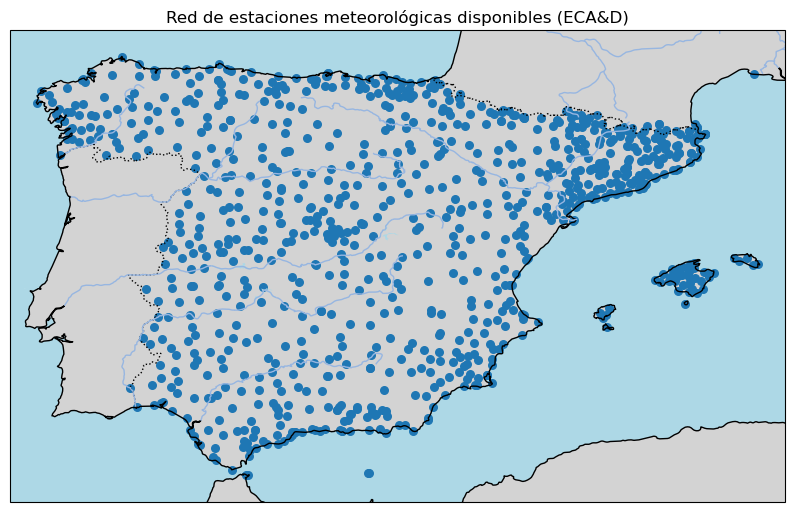

In [32]:
# Mapa de estaciones
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# -------------------------
# CREA EL MAPA
# -------------------------
plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

# Características básicas
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAKES, facecolor="lightblue")
ax.add_feature(cfeature.RIVERS)

# Scatter de tus puntos
ax.scatter(coVar_data["Longitud"], coVar_data["Latitud"],
           s=30,
           transform=ccrs.PlateCarree())

# Ajusta los límites del mapa según tus datos
margin = 0.5  # grados extra
ax.set_extent([
    coVar_data['Longitud'].min() - margin,
    coVar_data['Longitud'].max() + margin,
    coVar_data['Latitud'].min() - margin,
    coVar_data['Latitud'].max() + margin
], crs=ccrs.PlateCarree())

plt.title("Red de estaciones meteorológicas disponibles (ECA&D)")
plt.show()


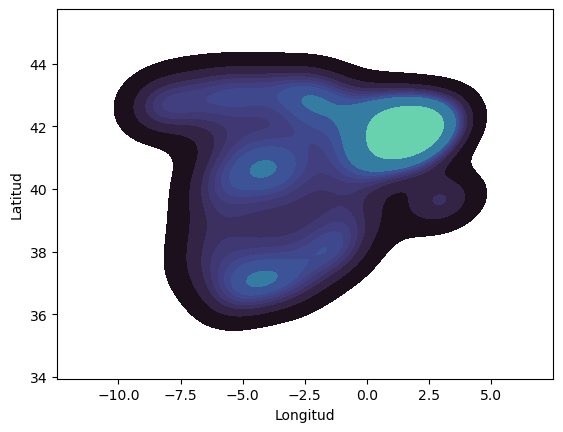

In [ ]:
# Mapa de densidad de estaciones
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(x=coVar_data['Longitud'], y=coVar_data['Latitud'], fill=True, cmap="mako")
plt.show()


### 1.2. Actividad de las estaciones

In [ ]:
# Análisis de datos faltantes por mes
# Crear columna 'YYYYMM' combinando Year y Month
tg_data['YYYYMM'] = tg_data['Year'].astype(str) + tg_data['Month'].astype(str).str.zfill(2)

# Contar cuántas estaciones tienen dato cada mes
tg_data['num_estaciones_disponibles'] = tg_data.drop(columns=['Year', 'Month', 'YYYYMM']).notna().sum(axis=1)

tg_data.head()


,229,230,231,232,233,234,235,236,237,238,...,27687,27689,27696,27700,27701,28075,Year,Month,YYYYMM,num_estaciones_disponibles
0,NaN,5.219355,11.732258,-1.493548,4.219355,8.093548,10.451613,10.009677,10.800000,6.796774,...,NaN,NaN,NaN,NaN,NaN,NaN,1951,1,195101,83
1,NaN,5.542857,12.642857,-3.907143,4.375000,7.667857,11.392857,10.450000,11.578571,6.689286,...,NaN,NaN,NaN,NaN,NaN,NaN,1951,2,195102,83
2,NaN,9.041935,15.032258,0.177419,7.348387,9.170968,13.774194,12.538710,13.267742,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1951,3,195103,80
3,NaN,12.206667,15.730000,3.460000,10.526667,11.326667,14.866667,14.086667,13.570000,11.860000,...,NaN,NaN,NaN,NaN,NaN,NaN,1951,4,195104,82
4,NaN,12.832258,18.693548,2.896774,10.961290,12.054839,17.370968,16.445161,16.654839,14.187097,...,NaN,NaN,NaN,NaN,NaN,NaN,1951,5,195105,87


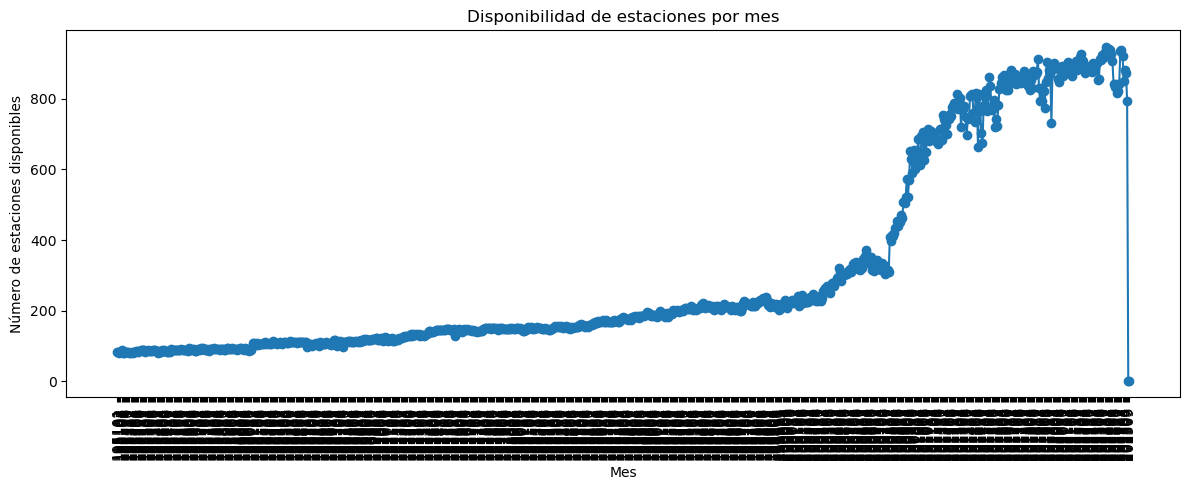

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(tg_data['YYYYMM'], tg_data['num_estaciones_disponibles'], marker='o')
plt.xticks(rotation=90)
plt.xlabel("Mes")
plt.ylabel("Número de estaciones disponibles")
plt.title("Disponibilidad de estaciones por mes")
plt.tight_layout()
plt.show()


In [23]:
# Crear un dataframe booleano: True si la estación tiene datos
availability = tg_data.drop(columns=['Year', 'Month', 'YYYYMM']).notna()

resultado = {}

for estacion in availability.columns:
    serie = availability[estacion]

    # Detectar cambios (True→False, False→True)
    cambios = serie.ne(serie.shift()).fillna(False)
    
    eventos = []
    for idx, cambio in cambios.items():
        if cambio:
            fecha = tg_data.loc[idx, 'YYYYMM']
            nuevo_estado = serie.loc[idx]
            eventos.append((fecha, "ACTIVA" if nuevo_estado else "INACTIVA"))
    
    resultado[estacion] = eventos


In [25]:
print(resultado)

{229: [('195101', 'INACTIVA'), ('195501', 'ACTIVA'), ('202508', 'INACTIVA')], 230: [('195101', 'ACTIVA'), ('202508', 'INACTIVA')], 231: [('195101', 'ACTIVA'), ('195608', 'INACTIVA'), ('195609', 'ACTIVA'), ('196106', 'INACTIVA'), ('196112', 'ACTIVA'), ('196201', 'INACTIVA'), ('196203', 'ACTIVA'), ('196204', 'INACTIVA'), ('196207', 'ACTIVA'), ('196208', 'INACTIVA'), ('196212', 'ACTIVA'), ('196302', 'INACTIVA'), ('196305', 'ACTIVA'), ('196307', 'INACTIVA'), ('196309', 'ACTIVA'), ('196311', 'INACTIVA'), ('196401', 'ACTIVA'), ('196404', 'INACTIVA'), ('196405', 'ACTIVA'), ('196502', 'INACTIVA'), ('196503', 'ACTIVA'), ('196506', 'INACTIVA'), ('196507', 'ACTIVA'), ('196510', 'INACTIVA'), ('196511', 'ACTIVA'), ('196512', 'INACTIVA'), ('196601', 'ACTIVA'), ('196603', 'INACTIVA'), ('196701', 'ACTIVA'), ('197309', 'INACTIVA'), ('197310', 'ACTIVA'), ('197707', 'INACTIVA'), ('197708', 'ACTIVA'), ('197709', 'INACTIVA'), ('197710', 'ACTIVA'), ('197712', 'INACTIVA'), ('197801', 'ACTIVA'), ('202508', 'I

In [29]:
del resultado['num_estaciones_disponibles']

In [30]:
print(resultado)

{229: [('195101', 'INACTIVA'), ('195501', 'ACTIVA'), ('202508', 'INACTIVA')], 230: [('195101', 'ACTIVA'), ('202508', 'INACTIVA')], 231: [('195101', 'ACTIVA'), ('195608', 'INACTIVA'), ('195609', 'ACTIVA'), ('196106', 'INACTIVA'), ('196112', 'ACTIVA'), ('196201', 'INACTIVA'), ('196203', 'ACTIVA'), ('196204', 'INACTIVA'), ('196207', 'ACTIVA'), ('196208', 'INACTIVA'), ('196212', 'ACTIVA'), ('196302', 'INACTIVA'), ('196305', 'ACTIVA'), ('196307', 'INACTIVA'), ('196309', 'ACTIVA'), ('196311', 'INACTIVA'), ('196401', 'ACTIVA'), ('196404', 'INACTIVA'), ('196405', 'ACTIVA'), ('196502', 'INACTIVA'), ('196503', 'ACTIVA'), ('196506', 'INACTIVA'), ('196507', 'ACTIVA'), ('196510', 'INACTIVA'), ('196511', 'ACTIVA'), ('196512', 'INACTIVA'), ('196601', 'ACTIVA'), ('196603', 'INACTIVA'), ('196701', 'ACTIVA'), ('197309', 'INACTIVA'), ('197310', 'ACTIVA'), ('197707', 'INACTIVA'), ('197708', 'ACTIVA'), ('197709', 'INACTIVA'), ('197710', 'ACTIVA'), ('197712', 'INACTIVA'), ('197801', 'ACTIVA'), ('202508', 'I

In [31]:
for estacion, eventos in resultado.items():  
    print(f"\n=== Estación {estacion} ===")
    for fecha, estado in eventos:
        print(f"{fecha}: {estado}")



=== Estación 229 ===
195101: INACTIVA
195501: ACTIVA
202508: INACTIVA

=== Estación 230 ===
195101: ACTIVA
202508: INACTIVA

=== Estación 231 ===
195101: ACTIVA
195608: INACTIVA
195609: ACTIVA
196106: INACTIVA
196112: ACTIVA
196201: INACTIVA
196203: ACTIVA
196204: INACTIVA
196207: ACTIVA
196208: INACTIVA
196212: ACTIVA
196302: INACTIVA
196305: ACTIVA
196307: INACTIVA
196309: ACTIVA
196311: INACTIVA
196401: ACTIVA
196404: INACTIVA
196405: ACTIVA
196502: INACTIVA
196503: ACTIVA
196506: INACTIVA
196507: ACTIVA
196510: INACTIVA
196511: ACTIVA
196512: INACTIVA
196601: ACTIVA
196603: INACTIVA
196701: ACTIVA
197309: INACTIVA
197310: ACTIVA
197707: INACTIVA
197708: ACTIVA
197709: INACTIVA
197710: ACTIVA
197712: INACTIVA
197801: ACTIVA
202508: INACTIVA

=== Estación 232 ===
195101: ACTIVA
202507: INACTIVA

=== Estación 233 ===
195101: ACTIVA
201509: INACTIVA
201510: ACTIVA
201601: INACTIVA
201602: ACTIVA
201610: INACTIVA
201611: ACTIVA
201807: INACTIVA
201808: ACTIVA
202508: INACTIVA

=== Esta

# 2. Análisis de las observaciones (tg) y covariables 